In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
from datetime import datetime as DT
from datetime import timedelta
import calendar
import seaborn as sns
from scipy.optimize import curve_fit as cf

import pmdarima as pmd

# Openning Data and Creating a Model

In [2]:
data = pd.read_csv('Nat_Gas.csv')
data['Dates'] = pd.to_datetime(data['Dates'], format="%m/%d/%y")
OG_data = data.copy()
data.set_index("Dates",inplace=True)

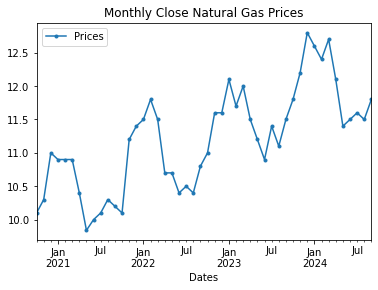

In [3]:
data.plot(style='.-',title="Monthly Close Natural Gas Prices");

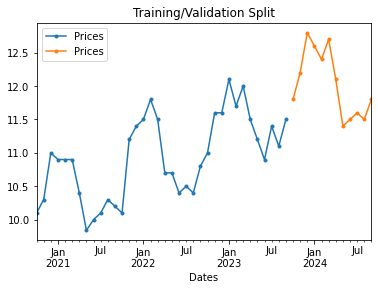

In [11]:
valid_start = -12

train = data.iloc[0:valid_start]
valid = data.iloc[valid_start:]

fig,ax = plt.subplots()
train.plot(ax=ax,style='.-')
valid.plot(ax=ax,style='.-')
ax.set_title("Training/Validation Split");

# Creating the Models

## SARIMA model

In [12]:
x_train = train.index
x_valid = valid.index

y_train = train["Prices"]
y_valid = valid["Prices"]

In [13]:
model_sarima = pmd.auto_arima(
    y_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    m=12,
    seasonal=True,
    trend='t',
    test='adf',
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True
)

print(model_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 -15.101
Date:                            Fri, 15 Aug 2025   AIC                             42.202
Time:                                    11:11:18   BIC                             51.703
Sample:                                10-31-2020   HQIC                            45.518
                                     - 09-30-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift          0.0010      0.001      0.932      0.352      -0.001       0.003
ar.L1          0.9948      0.008   

## Model Check

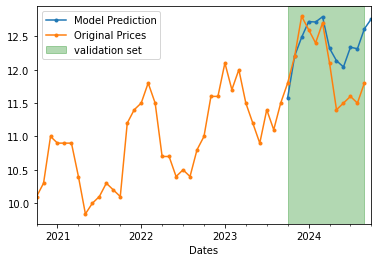

In [19]:
new_data_1 = pd.DataFrame(model_sarima.predict(n_periods=13))
fig, ax = plt.subplots()

lines1 = new_data_1.plot(ax=ax, style='.-').get_lines()
lines1 = ax.get_lines()[-len(new_data_1.columns):] 
lines1[0].set_label("Model Prediction")

lines2 = data.plot(ax=ax, style='.-').get_lines()
lines2 = ax.get_lines()[-len(data.columns):]
lines2[0].set_label("Original Prices")

ax.axvspan(data.index[valid_start],data.index[-1], alpha=0.3, color='green',label='validation set')
ax.legend()
plt.show()

## Brownian motion around time dependent mean

Sometimes, the simplest of models are better if we don't have a lot of data

In [15]:
# First we need to find a function for the mean
# It should oscillate and grown linearly in time

def Mean(t,A,B,C,D,E):
    return A*t + B*np.sin(C*t + D) + E

# let the time data have an arbitrary scale
X = np.arange(data["Prices"].size)

# Now fit the data, using all of it
MofT_FIT = cf(Mean,X,data["Prices"].values, p0=[0.5,3,0.5,0,10])
MofT_params = MofT_FIT[0]

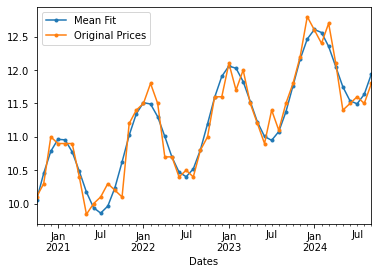

In [16]:
MofT = Mean(X,*MofT_params)
MofT = pd.DataFrame(MofT,columns=['Prices'])
MofT.index = data.index

fig,ax = plt.subplots()

lines1 = MofT.plot(ax=ax,style='.-').get_lines()
lines1 = ax.get_lines()
lines1[0].set_label("Mean Fit")

lines2 = data.plot(ax=ax,style='.-').get_lines()
lines2 = ax.get_lines()[-len(data.columns):]
lines2[0].set_label("Original Prices")

ax.legend();
plt.show();

Maximum Likelihood Estimation for variance: 0.039. Computing sample path..


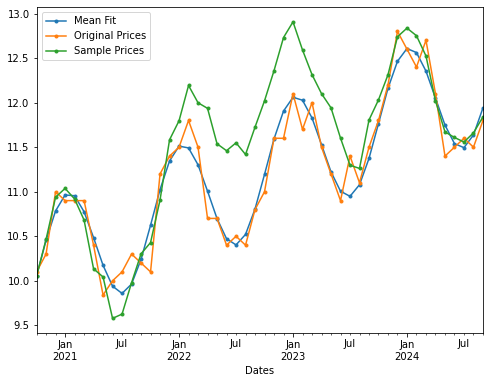

In [278]:
# Now, we know that the best estimate for the variance, is just the error in the fit!
var = (1/data['Prices'].size) * np.sum( ( data['Prices'] - MofT['Prices'] )**2 )
print("Maximum Likelihood Estimation for variance: {:.3f}. Computing sample path..".format(var))

# calculate path with random noise
n_steps = data['Prices'].size
noise = np.random.normal(0,1,size = n_steps-1)
dt = 1
dM = np.diff(MofT['Prices'].values)
sigma = np.sqrt(var)

# calculate steps with mean fit and most likely variance
increments = dM + sigma*np.sqrt(dt)*noise
path = np.zeros(n_steps)
path[0] = MofT['Prices'].values[0]

#calculate path is cumulative sum of increments and initial condition
path[1:] = np.cumsum(increments) + path[0]


fig,ax = plt.subplots(figsize=(8,6))

lines1 = MofT.plot(ax=ax,style='.-').get_lines()
lines1 = ax.get_lines()
lines1[0].set_label("Mean Fit")

lines2 = data.plot(ax=ax,style='.-').get_lines()
lines2 = ax.get_lines()[-len(data.columns):]
lines2[0].set_label("Original Prices")

path = pd.DataFrame(path,index=data.index,columns=['Sample Prices'])
path.plot(ax=ax,style='.-')

ax.legend();
plt.show();

# Computing list of dates

We will need this for testing our functions

In [93]:
def date_list(start_date_str, end_dat_str,last_day_of_month=False):
    """ Input a start and end date and output all dates in between, inclusive. Date string must be of the form:

        MM/DD/YY
        
        If last_day_of_month is true, it will only return the last day of the month beteen the the dates.
    """
    # Example input:
    # start_date_str = "8/31/24"
    # end_date_str = "12/7/26"

    start_date = DT.strptime(start_date_str, "%m/%d/%y")
    end_date = DT.strptime(end_date_str, "%m/%d/%y")
    days_delta = 1
    if last_day_of_month:
        last_day = calendar.monthrange(start_date.year, start_date.month)[1]
        start_date = start_date.replace(day=last_day)
        last_day = calendar.monthrange(end_date.year, end_date.month)[1]
        end_date = end_date.replace(day=last_day)
        days_delta = 7

    dates_list = []
    current_date = start_date
    while current_date <= end_date:
        dates_list.append(current_date)
        current_date += timedelta(days=days_delta)
        if last_day_of_month:
            last_day = calendar.monthrange(current_date.year, current_date.month)[1]
            current_date = current_date.replace(day=last_day)
    
    return pd.Series(pd.to_datetime(dates_list))

In [286]:
#### DELETE THIS LATER

start_date_str = "8/31/14"
end_date_str = "12/7/19"
test = date_list(start_date_str,end_date_str)
(test[0] - test).dt.days

0          0
1         -1
2         -2
3         -3
4         -4
        ... 
1920   -1920
1921   -1921
1922   -1922
1923   -1923
1924   -1924
Length: 1925, dtype: int64

# Past Estimations

We cannot use the SARIMA time series to make estimations of the past, so we only use our fitted model + noise for this.

In [374]:
def Simulate_Past(dates_list, n_paths=100,DOWNTUNE_SLOPE=1.0):
    """ 
    Function that takes in a list of dates in the past (relative to the original data) and
    returns n_paths simulations which can be used to estimate statistics.
    dates_list should be a pandas Series.
    """
    delta_days = (dates_list.sort_values(ascending=False) - data.index[0]).dt.days
    
    Last_Day = delta_days.iat[-1]
    if Last_Day > 0:
        print("Only past dates allowed.")
        return
#     n_paths = 100
    n_steps = abs(Last_Day)
    
    # Since we will now simulate DAILY values, we need to transfrom our rates (parameters)
    # Before we had delta_t ~ 1 month, so now we need to scale from months to days
    # Let's assume there are 365/12 = 30.4 days in a month and convert to the proper date afterwards
    dt = 1/30.4
    X = np.arange(0,Last_Day-1,-1,dtype=float)
    a,b,c,d,e = MofT_params
    # rescaling paramteres, only a and c need to be rescaled
    a *= dt
    c *= dt
    
    MofT = Mean(X,a*DOWNTUNE_SLOPE,b,c,d,e)
    noise = np.random.normal(0,1,size = (n_paths,n_steps))
    dM = np.diff(MofT)
    sigma = np.sqrt(var)

    # calculate steps with scaled mean fit and variance
    increments = dM + sigma*np.sqrt(dt)*noise
    paths = np.zeros((n_paths,n_steps+1))
    paths[:,0] = data['Prices'][0]
    
    #calculate path is cumulative sum of increments and initial condition
    paths[:,1:] = np.cumsum(increments, axis=1) + data['Prices'][0]
    
    X = pd.Series(X)
    new_date_index = data.index[0] + pd.to_timedelta(X, unit='D')
    paths = pd.DataFrame(paths.transpose(), index=new_date_index)
    
    return paths,MofT

def Estimate_Statistics(paths,past_MofT,print_all_values=False):
    """
    Function which takes in a pandas DataFrame of simulated paths and produces statistics and plots
    relevant for estimations (future or past)
    """
    Q25 = paths.quantile(q=0.25,axis=1)
    Q75 = paths.quantile(q=0.75,axis=1)
    median = paths.quantile(q=0.5,axis=1)

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(data.index,MofT,color='k',label="Data Average Price")
    ax.plot(paths.index,median,color='green',label='Median Simuated Path')
    ax.plot(paths.index,past_MofT,color='blue',label="Past Extrapolated Mean")
    ax.fill_between(paths.index,Q25,Q75,color='red',alpha=0.3,label='25% - 75%');
    ax.legend()
    plt.show()
    
    print("Final predicted value on {} given by simulation median: {:.3f}".format(paths.index[-1].strftime('%m/%d/%y'),median.iat[-1]))
    print("We expect the past value to lie between {:.3f} and {:.3f} with 50% confidence.".format(Q25.iat[-1],Q75.iat[-1]))
    if print_all_values:
        print("All predicted values given by simulations median:")
        print(median)

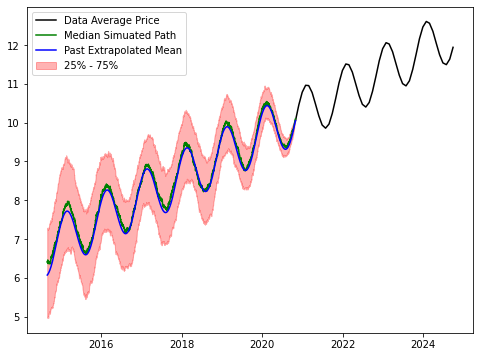

Final predicted value on 08/31/14 given by simulation median: 6.422
We expect the past value to lie between 4.974 and 7.278 with 50% confidence.


In [376]:
paths, past_MofT = Simulate_Past(test)
Estimate_Statistics(paths, past_MofT)

One might expect that the data is given during a particuarly inflationary time (COVID-19, war in Ukraine, etc). So, we also include a DOWNTUNE paramter to downsize the slope from the original fit. 

### Downtuned slope

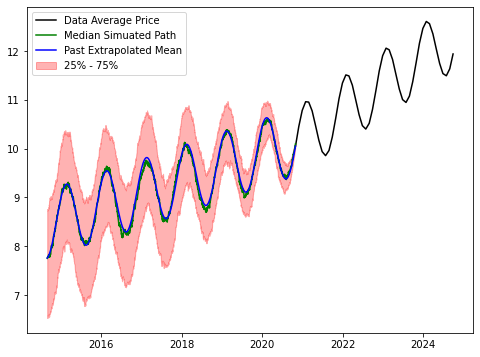

Final predicted value on 08/31/14 given by simulation median: 7.753
We expect the past value to lie between 6.531 and 8.756 with 50% confidence.


In [377]:
paths, past_MofT = Simulate_Past(test,DOWNTUNE_SLOPE=0.5)
Estimate_Statistics(paths, past_MofT)

# Future Extrapolation